In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

1. Data collection

In [4]:
ticker = "C6L.SI"

sia = yf.download(
    ticker,
    start="2015-01-01",
    end="2026-10-17",
    auto_adjust=False
)
if isinstance(sia.columns, pd.MultiIndex):
    sia.columns = sia.columns.get_level_values(0)

sia.head()

[*********************100%***********************]  1 of 1 completed


Price,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
2015-01-02,5.687865,8.137768,8.165951,8.116631,8.158905,759329
2015-01-05,5.707564,8.165951,8.180042,8.109585,8.130722,2363147
2015-01-06,5.751885,8.229362,8.229362,8.158905,8.187088,3570978
2015-01-07,5.889772,8.426641,8.426641,8.215271,8.229362,6361338
2015-01-08,5.919320,8.468915,8.468915,8.384367,8.440733,3961288


In [5]:
print(sia.head())
print(sia.tail())
print(sia.shape)
print(sia.columns)
print(sia.isnull().sum())

Price       Adj Close     Close      High       Low      Open   Volume
Date                                                                  
2015-01-02   5.687865  8.137768  8.165951  8.116631  8.158905   759329
2015-01-05   5.707564  8.165951  8.180042  8.109585  8.130722  2363147
2015-01-06   5.751885  8.229362  8.229362  8.158905  8.187088  3570978
2015-01-07   5.889772  8.426641  8.426641  8.215271  8.229362  6361338
2015-01-08   5.919320  8.468915  8.468915  8.384367  8.440733  3961288
Price       Adj Close  Close  High   Low  Open   Volume
Date                                                   
2026-09-30       6.74   6.74  6.78  6.69  6.69  4291600
2026-10-01       6.67   6.67  6.77  6.67  6.70  3952100
2026-10-02       6.66   6.66  6.71  6.58  6.69  4032500
2026-10-05       6.66   6.66  6.70  6.63  6.68  2181200
2026-10-06       6.70   6.70  6.72  6.64  6.72  2804000
(2955, 6)
Index(['Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='str', name='Price')
Price
Adj C

In [6]:
sia["Return"] = np.log(
    sia["Adj Close"] / sia["Adj Close"].shift(1)
)

sia.head()

sia = sia.dropna()

In [7]:
sia["Volatility_21D"] = sia["Return"].rolling(window=21).std()

sia["Volatility_21D_Annualized"] = (
    sia["Volatility_21D"] * np.sqrt(252)
)

In [8]:
train = sia.loc["2015-01-01":"2023-06-30"].copy()

validation1 = sia.loc["2023-07-01":"2024-12-31"].copy()

validation2 = sia.loc["2025-01-01":"2026-06-30"].copy()

test = sia.loc["2026-10-01":"2026-10-16"].copy()

In [9]:
print("Train:")
print(train.index.min(), "to", train.index.max())
print("Observations:", len(train))

print("\nValidation 1:")
print(validation1.index.min(), "to", validation1.index.max())
print("Observations:", len(validation1))

print("\nValidation 2:")
print(validation2.index.min(), "to", validation2.index.max())
print("Observations:", len(validation2))

print("\nTest:")
print(test.index.min(), "to", test.index.max())
print("Observations:", len(test))

Train:
2015-01-05 00:00:00 to 2023-06-30 00:00:00
Observations: 2132

Validation 1:
2023-07-03 00:00:00 to 2024-12-31 00:00:00
Observations: 378

Validation 2:
2025-01-02 00:00:00 to 2026-06-30 00:00:00
Observations: 375

Test:
2026-10-01 00:00:00 to 2026-10-06 00:00:00
Observations: 4


2. TRAIN data time series analysis

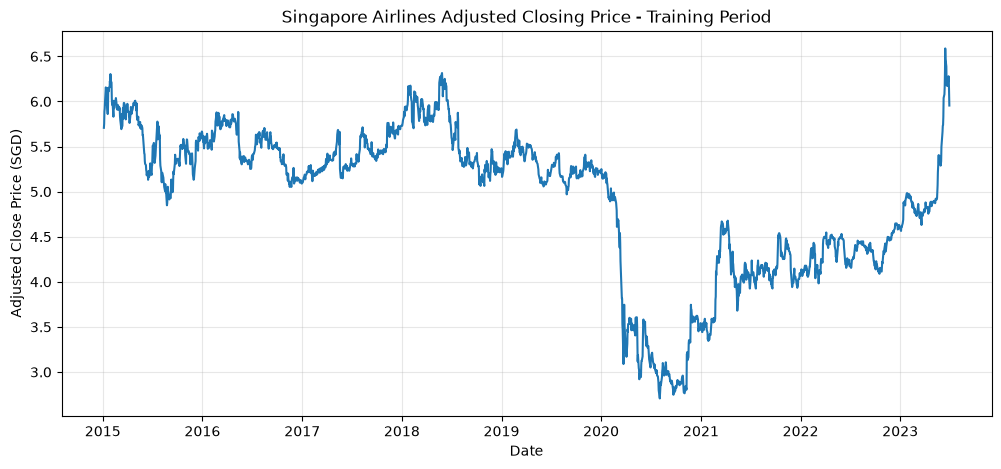

In [10]:
plt.figure(figsize=(12, 5))

plt.plot(train.index, train["Adj Close"])

plt.title("Singapore Airlines Adjusted Closing Price - Training Period")
plt.xlabel("Date")
plt.ylabel("Adjusted Close Price (SGD)")
plt.grid(alpha=0.3)

plt.show()

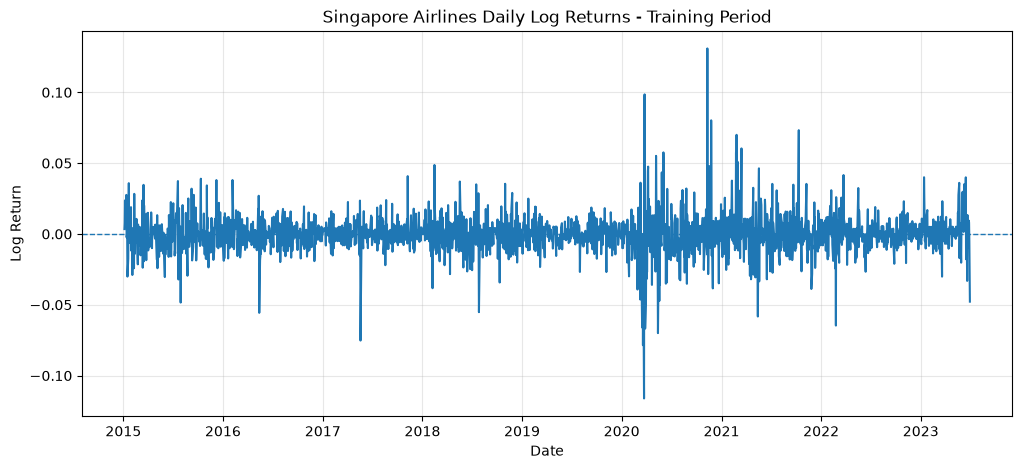

In [11]:
plt.figure(figsize=(12, 5))

plt.plot(train.index, train["Return"])

plt.axhline(y=0, linestyle="--", linewidth=1)

plt.title("Singapore Airlines Daily Log Returns - Training Period")
plt.xlabel("Date")
plt.ylabel("Log Return")

plt.grid(alpha=0.3)
plt.show()

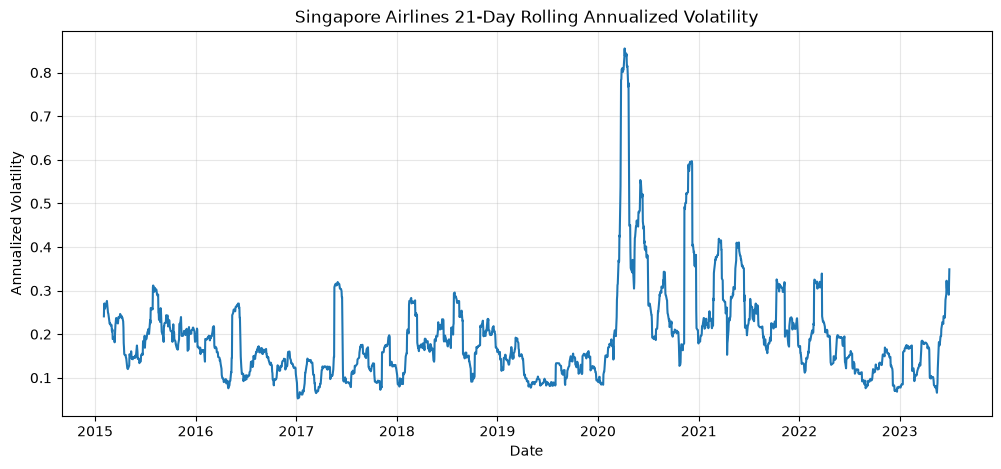

In [12]:
plt.figure(figsize=(12, 5))

plt.plot(
    train.index,
    train["Volatility_21D_Annualized"]
)

plt.title("Singapore Airlines 21-Day Rolling Annualized Volatility")
plt.xlabel("Date")
plt.ylabel("Annualized Volatility")

plt.grid(alpha=0.3)
plt.show()

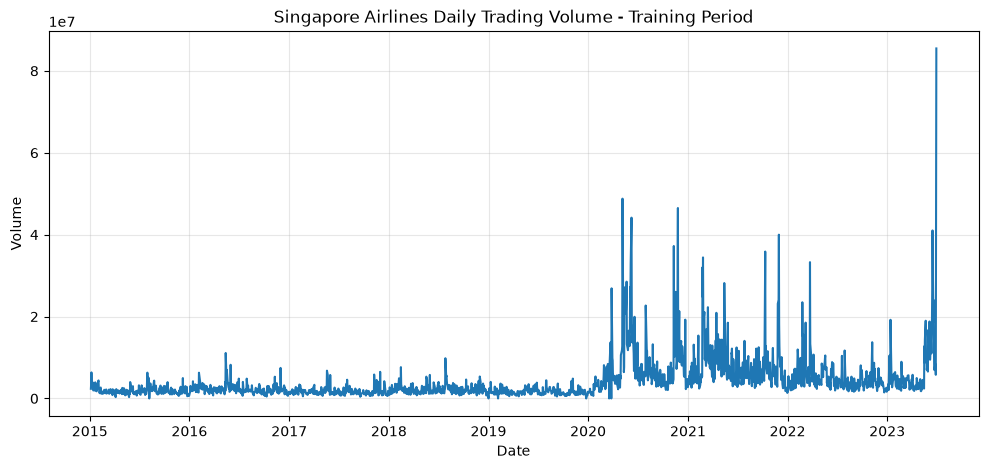

In [13]:
plt.figure(figsize=(12, 5))

plt.plot(train.index, train["Volume"])

plt.title("Singapore Airlines Daily Trading Volume - Training Period")
plt.xlabel("Date")
plt.ylabel("Volume")

plt.grid(alpha=0.3)
plt.show()

In [14]:
train[["Adj Close", "Return", "Volume", "Volatility_21D_Annualized"]].describe()

Price,Adj Close,Return,Volume,Volatility_21D_Annualized
count,2132.000000,2132.000000,2.132000e+03,2112.000000
mean,4.927725,0.000021,4.061213e+06,0.191692
std,0.820902,0.013938,4.981177e+06,0.107323
min,2.707033,-0.116123,0.000000e+00,0.052598
25%,4.350881,-0.006625,1.582670e+06,0.125513
50%,5.210474,0.000000,2.470466e+06,0.168596
75%,5.492023,0.006011,4.641746e+06,0.223275
max,6.587554,0.130977,8.547230e+07,0.855421


In [15]:
from scipy.stats import skew, kurtosis

returns = train["Return"].dropna()

print("Mean:", returns.mean())
print("Standard deviation:", returns.std())
print("Skewness:", skew(returns))
print("Excess kurtosis:", kurtosis(returns))

Mean: 2.1497094572309515e-05
Standard deviation: 0.013938097858229933
Skewness: 0.3977867598470716
Excess kurtosis: 11.808780810011333


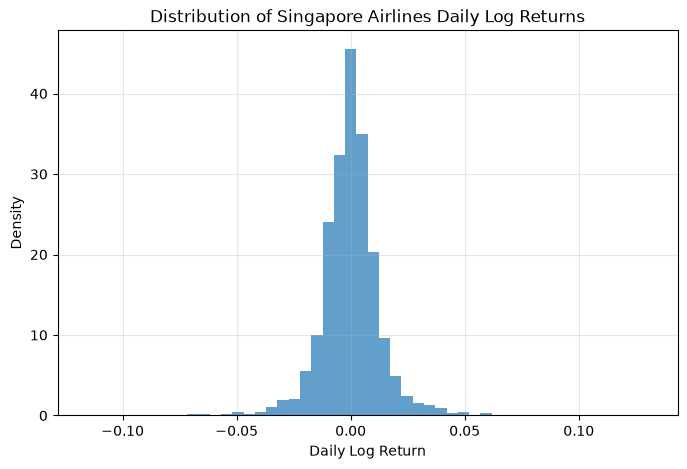

In [16]:
plt.figure(figsize=(8, 5))

plt.hist(
    returns,
    bins=50,
    density=True,
    alpha=0.7
)

plt.title("Distribution of Singapore Airlines Daily Log Returns")
plt.xlabel("Daily Log Return")
plt.ylabel("Density")

plt.grid(alpha=0.3)
plt.show()

Preliminary observations:
Singapore Airlines' daily log returns are centered approximately around zero but exhibit substantial variability and extreme observations. The return distribution is positively skewed (0.398) and highly leptokurtic, with excess kurtosis of 11.81, indicating substantial departures from normality and fat tails.  
The return and rolling-volatility plots also provide visual evidence of volatility clustering, particularly during the 2020–2021 period, when the COVID-19 pandemic severely affected the aviation industry. Annualized 21-day rolling volatility increased sharply during this period. Trading volume also increased substantially from 2020 onward. These observations motivate further investigation of both return dynamics and conditional heteroskedasticity using time-series models.

3. Stationarity

In [17]:
from statsmodels.tsa.stattools import adfuller

price_adf = adfuller(train["Adj Close"].dropna())

print("ADF Test - Adjusted Close Price")
print("ADF Statistic:", price_adf[0])
print("p-value:", price_adf[1])

for key, value in price_adf[4].items():
    print(f"Critical Value ({key}): {value}")

ADF Test - Adjusted Close Price
ADF Statistic: -1.680465706702163
p-value: 0.4412041910134923
Critical Value (1%): -3.43342235783426
Critical Value (5%): -2.8628972480890464
Critical Value (10%): -2.567492533158371


C:\Users\jhzha\AppData\Local\Temp\ipykernel_36708\2144822562.py:3: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  price_adf = adfuller(train["Adj Close"].dropna())


In [18]:
return_adf = adfuller(train["Return"].dropna())

print("ADF Test - Daily Log Returns")
print("ADF Statistic:", return_adf[0])
print("p-value:", return_adf[1])

for key, value in return_adf[4].items():
    print(f"Critical Value ({key}): {value}")

ADF Test - Daily Log Returns
ADF Statistic: -10.921961903939732
p-value: 1.0326232180151605e-19
Critical Value (1%): -3.4334485622083744
Critical Value (5%): -2.8629088181514795
Critical Value (10%): -2.567498693511355


C:\Users\jhzha\AppData\Local\Temp\ipykernel_36708\2920956042.py:1: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  return_adf = adfuller(train["Return"].dropna())


Stationarity analysis:
The ADF test for Singapore Airlines' adjusted closing price produces a test statistic of −1.680 and a p-value of 0.441. Therefore, the null hypothesis of a unit root cannot be rejected at conventional significance levels, suggesting that the price series is non-stationary.
In contrast, the daily log-return series produces an ADF statistic of −10.922 with a p-value below 0.001. The unit-root null hypothesis is therefore strongly rejected, indicating that daily log returns are stationary. Consequently, subsequent conditional-mean modelling is performed on daily log returns rather than the price level.

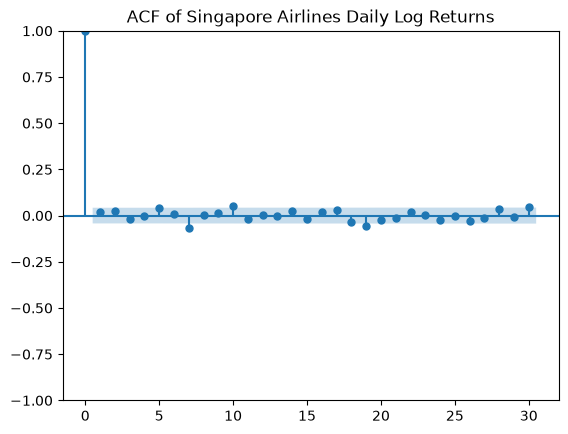

In [19]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

returns = train["Return"].dropna()

plot_acf(returns, lags=30)
plt.title("ACF of Singapore Airlines Daily Log Returns")
plt.show()

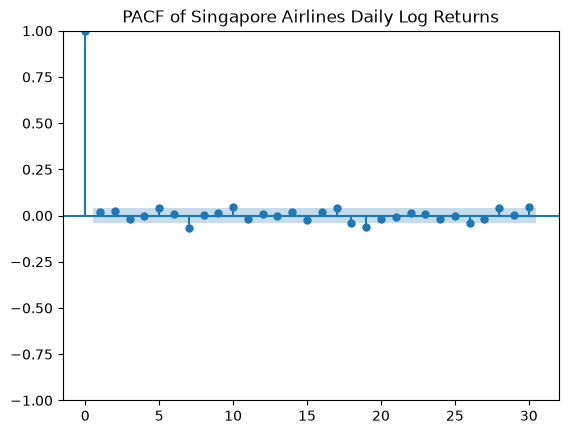

In [20]:
plot_pacf(returns, lags=30, method="ywm")
plt.title("PACF of Singapore Airlines Daily Log Returns")
plt.show()

3A ARIMA ARMA

In [21]:
from statsmodels.tsa.arima.model import ARIMA
import pandas as pd

returns = train["Return"].dropna()

results = []

orders = [
    (0, 0),
    (1, 0),
    (0, 1),
    (1, 1),
    (2, 0),
    (0, 2),
    (2, 1),
    (1, 2),
    (2, 2)
]

for p, q in orders:
    model = ARIMA(returns, order=(p, 0, q))
    fitted = model.fit()

    results.append({
        "Model": f"ARMA({p},{q})",
        "AIC": fitted.aic,
        "BIC": fitted.bic
    })

arma_comparison = pd.DataFrame(results)

arma_comparison = arma_comparison.sort_values("AIC")

arma_comparison

c:\Users\jhzha\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g., forecasting.
  self._init_dates(dates, freq)
c:\Users\jhzha\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g., forecasting.
  self._init_dates(dates, freq)
c:\Users\jhzha\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g., forecasting.
  self._init_dates(dates, freq)
c:\Users\jhzha\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: A date index has been 

,Model,AIC,BIC
0,"ARMA(0,0)",-12167.268990,-12155.939358
1,"ARMA(1,0)",-12165.922675,-12148.928228
2,"ARMA(0,1)",-12165.893620,-12148.899172
5,"ARMA(0,2)",-12165.072855,-12142.413592
4,"ARMA(2,0)",-12165.013468,-12142.354205
3,"ARMA(1,1)",-12163.886002,-12141.226738
6,"ARMA(2,1)",-12163.757392,-12135.433313
7,"ARMA(1,2)",-12163.166398,-12134.842319
8,"ARMA(2,2)",-12161.045913,-12127.057018


In [22]:
mean_model = ARIMA(
    returns,
    order=(0, 0, 0)
)

mean_result = mean_model.fit()

print(mean_result.summary())
residuals = mean_result.resid

c:\Users\jhzha\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g., forecasting.
  self._init_dates(dates, freq)
c:\Users\jhzha\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g., forecasting.
  self._init_dates(dates, freq)
c:\Users\jhzha\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g., forecasting.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                 Return   No. Observations:                 2132
Model:                          ARIMA   Log Likelihood                6085.634
Date:                Tue, 06 Oct 2026   AIC                         -12167.269
Time:                        23:40:57   BIC                         -12155.939
Sample:                             0   HQIC                        -12163.122
                               - 2132                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       1.649e-05      0.000      0.054      0.957      -0.001       0.001
sigma2         0.0002   2.28e-06     85.237      0.000       0.000       0.000
Ljung-Box (L1) (Q):                   0.65   Jarque-

In [26]:
from statsmodels.stats.diagnostic import acorr_ljungbox

lb_test = acorr_ljungbox(
    residuals,
    lags=[10, 20],
    return_df=True
)

lb_test

,lb_stat,lb_pvalue
10,21.596989,0.017295
20,38.638000,0.007393


In [27]:
from statsmodels.stats.diagnostic import het_arch

arch_test = het_arch(residuals, nlags=10)

print("ARCH LM Statistic:", arch_test[0])
print("ARCH LM p-value:", arch_test[1])

ARCH LM Statistic: 317.16305869027076
ARCH LM p-value: 3.6369664442413912e-62


c:\Users\jhzha\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\stats\diagnostic.py:997: FutureWarning: acorr_lm currently returns a plain tuple whose length depends on the store argument. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an LMTestResult NamedTuple. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  return acorr_lm(


Residual and ARCH diagnostics:
Although ARMA(0,0) achieves the lowest AIC and BIC among the candidate conditional-mean specifications, the Ljung–Box tests at lags 10 and 20 produce p-values of 0.017 and 0.007, respectively, indicating some remaining serial correlation in the residuals. Thus, the constant-mean specification does not fully eliminate return dependence.
More importantly, the ARCH-LM test strongly rejects the null hypothesis of no ARCH effects (LM = 317.16, p < 0.001). This provides strong statistical evidence of conditional heteroskedasticity in SIA returns and supports the use of ARCH/GARCH-type models for conditional volatility. The Jarque–Bera test also rejects normality, consistent with the substantial excess kurtosis observed previously.

3B GARCH

In [28]:
from arch import arch_model

returns_pct = train["Return"].dropna() * 100

garch_11 = arch_model(
    returns_pct,
    mean="Constant",
    vol="GARCH",
    p=1,
    q=1,
    dist="normal"
)

garch_11_result = garch_11.fit(disp="off")

print(garch_11_result.summary())

                     Constant Mean - GARCH Model Results                      
Dep. Variable:                 Return   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -3431.64
Distribution:                  Normal   AIC:                           6871.28
Method:            Maximum Likelihood   BIC:                           6893.94
                                        No. Observations:                 2132
Date:                Tue, Oct 06 2026   Df Residuals:                     2131
Time:                        23:46:45   Df Model:                            1
                                  Mean Model                                 
                 coef    std err          t      P>|t|       95.0% Conf. Int.
-----------------------------------------------------------------------------
mu             0.0216  2.365e-02      0.914      0.361 

In [29]:
vol_results = []

models = {
    "ARCH(1)-Normal": arch_model(
        returns_pct, mean="Constant",
        vol="ARCH", p=1,
        dist="normal"
    ),

    "GARCH(1,1)-Normal": arch_model(
        returns_pct, mean="Constant",
        vol="GARCH", p=1, q=1,
        dist="normal"
    ),

    "GARCH(1,1)-t": arch_model(
        returns_pct, mean="Constant",
        vol="GARCH", p=1, q=1,
        dist="t"
    ),

    "GARCH(2,1)-t": arch_model(
        returns_pct, mean="Constant",
        vol="GARCH", p=2, q=1,
        dist="t"
    ),

    "GARCH(1,2)-t": arch_model(
        returns_pct, mean="Constant",
        vol="GARCH", p=1, q=2,
        dist="t"
    )
}

for name, model in models.items():
    result = model.fit(disp="off")

    vol_results.append({
        "Model": name,
        "Log-Likelihood": result.loglikelihood,
        "AIC": result.aic,
        "BIC": result.bic
    })

vol_comparison = pd.DataFrame(vol_results)
vol_comparison = vol_comparison.sort_values("AIC")

vol_comparison

,Model,Log-Likelihood,AIC,BIC
2,"GARCH(1,1)-t",-3266.943776,6543.887551,6572.211630
4,"GARCH(1,2)-t",-3266.507574,6545.015148,6579.004043
3,"GARCH(2,1)-t",-3266.943776,6545.887551,6579.876446
1,"GARCH(1,1)-Normal",-3431.637959,6871.275918,6893.935181
0,ARCH(1)-Normal,-3645.483011,7296.966022,7313.960469


In [30]:
selected_garch = arch_model(
    returns_pct,
    mean="Constant",
    vol="GARCH",
    p=1,
    q=1,
    dist="t"
)

selected_garch_result = selected_garch.fit(disp="off")

print(selected_garch_result.summary())

                        Constant Mean - GARCH Model Results                         
Dep. Variable:                       Return   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                            GARCH   Log-Likelihood:               -3266.94
Distribution:      Standardized Student's t   AIC:                           6543.89
Method:                  Maximum Likelihood   BIC:                           6572.21
                                              No. Observations:                 2132
Date:                      Tue, Oct 06 2026   Df Residuals:                     2131
Time:                              23:48:52   Df Model:                            1
                                  Mean Model                                 
                 coef    std err          t      P>|t|       95.0% Conf. Int.
-----------------------------------------------------------------------------
m

In [31]:
std_resid = selected_garch_result.std_resid.dropna()

lb_std = acorr_ljungbox(
    std_resid,
    lags=[10, 20],
    return_df=True
)

print("Ljung-Box test on standardized residuals:")
print(lb_std)

Ljung-Box test on standardized residuals:
      lb_stat  lb_pvalue
10  13.699378   0.187151
20  25.397029   0.186662


In [32]:
lb_std_sq = acorr_ljungbox(
    std_resid**2,
    lags=[10, 20],
    return_df=True
)

print("\nLjung-Box test on squared standardized residuals:")
print(lb_std_sq)


Ljung-Box test on squared standardized residuals:
     lb_stat  lb_pvalue
10  5.020930   0.889775
20  9.536059   0.975826


GARCH model selection and diagnostics:
Among the candidate volatility specifications, GARCH(1,1) with Student-t innovations achieved the lowest AIC and BIC. The estimated ARCH and GARCH coefficients are statistically significant, with \(\alpha_1=0.130\) and \(\beta_1=0.849\). Their sum of approximately 0.979 indicates high volatility persistence, although the process remains mean-reverting.
The estimated Student-t degrees-of-freedom parameter is approximately 4.07, consistent with the heavy-tailed return distribution observed during the exploratory analysis. Ljung–Box tests on standardized residuals at lags 10 and 20 fail to reject the null of no autocorrelation. Tests on squared standardized residuals also fail to reject the null, suggesting that the fitted GARCH(1,1)-t specification captures the principal conditional heteroskedasticity present in the training sample.

4. Validation

In [33]:
val1_returns = validation1["Return"].dropna() * 100

print("Validation 1 observations:", len(val1_returns))
print("Start:", val1_returns.index.min())
print("End:", val1_returns.index.max())

Validation 1 observations: 378
Start: 2023-07-03 00:00:00
End: 2024-12-31 00:00:00


In [34]:
val1_dates = validation1.index

vol_forecasts = []

for date in val1_dates:

    # Use only observations BEFORE the validation date
    historical_returns = (
        sia.loc[sia.index < date, "Return"]
        .dropna()
        * 100
    )

    model = arch_model(
        historical_returns,
        mean="Constant",
        vol="GARCH",
        p=1,
        q=1,
        dist="t"
    )

    result = model.fit(disp="off")

    forecast = result.forecast(horizon=1)

    forecast_variance = forecast.variance.iloc[-1, 0]

    forecast_volatility = np.sqrt(forecast_variance)

    vol_forecasts.append(forecast_volatility)

In [35]:
validation_forecasts = pd.DataFrame(
    {
        "Actual_Return": val1_returns,
        "Forecast_Volatility": vol_forecasts
    },
    index=val1_dates
)

validation_forecasts.head()

,Actual_Return,Forecast_Volatility
Date,,
2023-07-03,2.486319,2.293679
2023-07-04,-1.928441,2.310885
2023-07-05,-0.139184,2.253892
2023-07-06,0.416964,2.088275
2023-07-07,1.514153,1.943243


In [36]:
validation_forecasts["Forecast_Variance"] = (
    validation_forecasts["Forecast_Volatility"] ** 2
)

validation_forecasts["Realized_Variance_Proxy"] = (
    validation_forecasts["Actual_Return"] ** 2
)

validation_forecasts.head()

,Actual_Return,Forecast_Volatility,Forecast_Variance,Realized_Variance_Proxy
Date,,,,
2023-07-03,2.486319,2.293679,5.260963,6.181784
2023-07-04,-1.928441,2.310885,5.340192,3.718886
2023-07-05,-0.139184,2.253892,5.080029,0.019372
2023-07-06,0.416964,2.088275,4.360891,0.173859
2023-07-07,1.514153,1.943243,3.776195,2.292660


In [37]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

mse = mean_squared_error(
    validation_forecasts["Realized_Variance_Proxy"],
    validation_forecasts["Forecast_Variance"]
)

mae = mean_absolute_error(
    validation_forecasts["Realized_Variance_Proxy"],
    validation_forecasts["Forecast_Variance"]
)

print("Volatility Forecast MSE:", mse)
print("Volatility Forecast MAE:", mae)

Volatility Forecast MSE: 32.515796778753035
Volatility Forecast MAE: 1.6987790068707271


In [38]:
naive_variance_forecasts = []

for date in val1_dates:

    historical_returns = (
        sia.loc[sia.index < date, "Return"]
        .dropna()
        * 100
    )

    naive_variance = historical_returns.iloc[-21:].var()

    naive_variance_forecasts.append(naive_variance)

validation_forecasts["Naive_Variance"] = naive_variance_forecasts

In [39]:
naive_mse = mean_squared_error(
    validation_forecasts["Realized_Variance_Proxy"],
    validation_forecasts["Naive_Variance"]
)

naive_mae = mean_absolute_error(
    validation_forecasts["Realized_Variance_Proxy"],
    validation_forecasts["Naive_Variance"]
)

print("GARCH MSE:", mse)
print("Naive MSE:", naive_mse)

print("\nGARCH MAE:", mae)
print("Naive MAE:", naive_mae)

GARCH MSE: 32.515796778753035
Naive MSE: 33.10609997119173

GARCH MAE: 1.6987790068707271
Naive MAE: 1.6863853797238535


In [40]:
validation_forecasts["Absolute_Return"] = (
    validation_forecasts["Actual_Return"].abs()
)

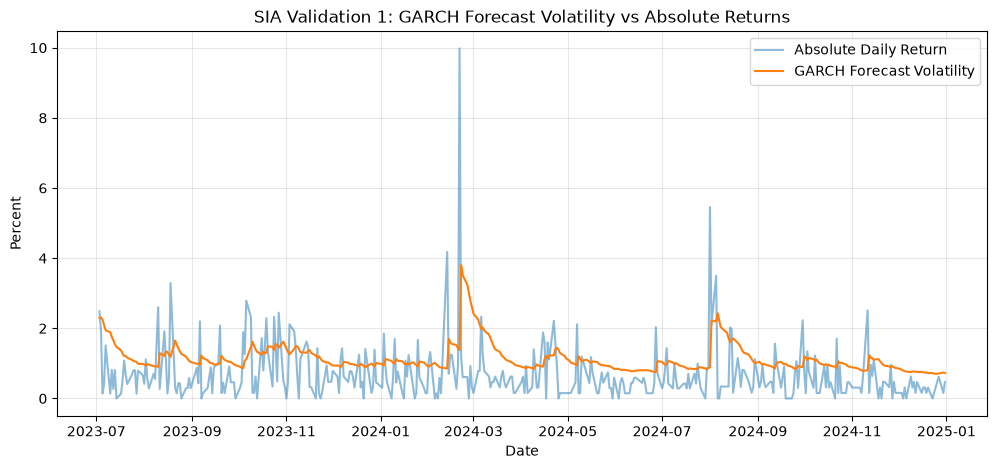

In [41]:
plt.figure(figsize=(12, 5))

plt.plot(
    validation_forecasts.index,
    validation_forecasts["Absolute_Return"],
    label="Absolute Daily Return",
    alpha=0.5
)

plt.plot(
    validation_forecasts.index,
    validation_forecasts["Forecast_Volatility"],
    label="GARCH Forecast Volatility"
)

plt.title(
    "SIA Validation 1: GARCH Forecast Volatility vs Absolute Returns"
)

plt.xlabel("Date")
plt.ylabel("Percent")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

Validation 1 — Volatility forecasting:
Rolling one-step-ahead forecasts were generated using an expanding-window GARCH(1,1)-t model over the Validation 1 period. The GARCH model achieved an MSE of 32.516 compared with 33.106 for a 21-day historical-variance benchmark, representing a modest improvement of approximately 1.8%. However, the GARCH MAE (1.699) was slightly higher than that of the benchmark (1.686). Thus, GARCH does not uniformly dominate the simpler historical-volatility model out of sample. Nevertheless, the forecasts dynamically respond to large volatility shocks and subsequently decay, consistent with the high volatility persistence estimated during training.

In [42]:
actual_var = validation_forecasts["Realized_Variance_Proxy"]

garch_var = validation_forecasts["Forecast_Variance"]

naive_var = validation_forecasts["Naive_Variance"]

garch_qlike = np.mean(
    np.log(garch_var)
    + actual_var / garch_var
)

naive_qlike = np.mean(
    np.log(naive_var)
    + actual_var / naive_var
)

print("GARCH QLIKE:", garch_qlike)
print("Naive QLIKE:", naive_qlike)

GARCH QLIKE: 1.1189896546573412
Naive QLIKE: 1.4066787521404698


SIA volatility appears forecastable.

In [46]:
from statsmodels.tsa.arima.model import ARIMA

val1_dates = validation1.index
actual_returns = validation1["Return"] * 100

arma_orders = {
    "ARMA(0,0)": (0, 0, 0),
    "ARMA(1,0)": (1, 0, 0),
    "ARMA(0,1)": (0, 0, 1),
    "ARMA(1,1)": (1, 0, 1)
}

return_forecasts = pd.DataFrame(index=val1_dates)
return_forecasts["Actual_Return"] = actual_returns

for name, order in arma_orders.items():

    forecasts = []

    for date in val1_dates:

        historical_returns = (
            sia.loc[sia.index < date, "Return"]
            .dropna()
            * 100
        )

        # Remove the date index because ARMA only needs the return values
        historical_returns = historical_returns.reset_index(drop=True)

        model = ARIMA(
            historical_returns,
            order=order
        )

        result = model.fit()

        forecast = np.asarray(
            result.forecast(steps=1)
        ).item()

        forecasts.append(forecast)

    return_forecasts[name] = forecasts

return_forecasts.head()

,Actual_Return,"ARMA(0,0)","ARMA(1,0)","ARMA(0,1)","ARMA(1,1)"
Date,,,,,
2023-07-03,2.486319,0.002145,-0.081779,-0.077845,-0.090507
2023-07-04,-1.928441,0.003309,0.039535,0.038865,0.000288
2023-07-05,-0.139184,0.002404,-0.023485,-0.022651,-0.032007
2023-07-06,0.416964,0.002338,0.000435,0.000849,-0.020455
2023-07-07,1.514153,0.002532,0.008109,0.007862,-0.003944


In [47]:
forecast_results = []

actual = return_forecasts["Actual_Return"]

for name in arma_orders.keys():

    forecast = return_forecasts[name]

    rmse = np.sqrt(
        np.mean((actual - forecast) ** 2)
    )

    mae = np.mean(
        np.abs(actual - forecast)
    )

    forecast_results.append({
        "Model": name,
        "RMSE": rmse,
        "MAE": mae
    })

return_performance = pd.DataFrame(forecast_results)

return_performance.sort_values("RMSE")

,Model,RMSE,MAE
3,"ARMA(1,1)",1.082326,0.695351
1,"ARMA(1,0)",1.082420,0.694911
2,"ARMA(0,1)",1.082489,0.694926
0,"ARMA(0,0)",1.083798,0.695714


In [48]:
zero_forecast = np.zeros(len(actual))

zero_rmse = np.sqrt(
    np.mean((actual - zero_forecast) ** 2)
)

zero_mae = np.mean(
    np.abs(actual - zero_forecast)
)

print("Zero Forecast RMSE:", zero_rmse)
print("Zero Forecast MAE:", zero_mae)

Zero Forecast RMSE: 1.0835712414490082
Zero Forecast MAE: 0.6954323109892588


In [49]:
positive_day_rate = (
    return_forecasts["Actual_Return"] > 0
).mean()

print(
    "Percentage of positive-return days:",
    round(positive_day_rate * 100, 2),
    "%"
)

Percentage of positive-return days: 45.5 %


In [50]:
for name in arma_orders.keys():

    correct_direction = (
        np.sign(return_forecasts[name])
        ==
        np.sign(return_forecasts["Actual_Return"])
    )

    directional_accuracy = correct_direction.mean()

    print(
        name,
        "Directional Accuracy:",
        round(directional_accuracy * 100, 2),
        "%"
    )

ARMA(0,0) Directional Accuracy: 45.24 %
ARMA(1,0) Directional Accuracy: 51.06 %
ARMA(0,1) Directional Accuracy: 51.06 %
ARMA(1,1) Directional Accuracy: 48.68 %
